In [4]:
#importing libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [5]:
#loading dataset
df = pd.read_csv('train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
#checking for missing values
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [9]:
#Cleaning missing values
# Embarked: Impute 2 missing values with mode ('S')
df["Embarked"] = df["Embarked"].fillna("S")

# Cabin: Create binary indicator and extract Deck letter
df["Has_Cabin"] = df["Cabin"].notnull().astype(int)
df["Deck"] = df["Cabin"].apply(lambda x: str(x)[0] if pd.notnull(x) else "Unknown")

# Age: Extract Title from Name and impute by median of (Title, Pclass)
df["Title"] = df["Name"].str.extract(r" ([A-Za-z]+)\.", expand=False)

# Consolidating rare titles for cleaner grouping
title_map = {
    "Mlle": "Miss",
    "Ms": "Miss",
    "Mme": "Mrs",
    "Lady": "Royalty",
    "Countess": "Royalty",
    "Dona": "Royalty",
    "Sir": "Royalty",
    "Jonkheer": "Royalty",
    "Don": "Royalty",
    "Capt": "Officer",
    "Col": "Officer",
    "Major": "Officer",
    "Dr": "Officer",
    "Rev": "Officer",
}
df["Title"] = df["Title"].replace(title_map)

# Impute missing Age using median grouped by Title and Pclass
df["Age"] = df.groupby(["Title", "Pclass"])["Age"].transform(
    lambda s: s.fillna(s.median())
)

# Fallback in case any group has all nulls
df["Age"] = df.groupby("Title")["Age"].transform(lambda s: s.fillna(s.median()))
df["Age"] = df["Age"].fillna(df["Age"].median())

# Verification
print(df[["Age", "Embarked", "Has_Cabin", "Deck"]].isnull().sum())

Age          0
Embarked     0
Has_Cabin    0
Deck         0
dtype: int64


In [10]:
#Converting to correct dtypes
# Convert Pclass to an ordered categorical type (1st > 2nd > 3rd class)
df["Pclass"] = pd.Categorical(df["Pclass"], categories=[1, 2, 3], ordered=True)

# Convert Sex and Embarked to nominal categorical types
df["Sex"] = df["Sex"].astype("category")
df["Embarked"] = df["Embarked"].astype("category")

# Verify updated data types and memory usage
print("\nData types after conversion:")
print(df[["Pclass", "Sex", "Embarked"]].dtypes)
print("\nDataFrame info summary:")
df[["Pclass", "Sex", "Embarked"]].info()


Data types after conversion:
Pclass      category
Sex         category
Embarked    category
dtype: object

DataFrame info summary:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   Pclass    891 non-null    category
 1   Sex       891 non-null    category
 2   Embarked  891 non-null    category
dtypes: category(3)
memory usage: 3.1 KB


In [11]:
# Survival rates across Titles
title_survival = df.groupby("Title", observed=False)["Survived"].agg(
    Total="count", Survived="sum", Survival_Rate="mean"
)
print("--- Survival by Title ---")
print(title_survival)

--- Survival by Title ---
         Total  Survived  Survival_Rate
Title                                  
Master      40        23       0.575000
Miss       185       130       0.702703
Mr         517        81       0.156673
Mrs        126       100       0.793651
Officer     18         5       0.277778
Royalty      5         3       0.600000


In [12]:
# Discretize Age into standard cohorts
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0, 12, 19, 59, 100],
    labels=["Child (<=12)", "Teen (13-19)", "Adult (20-59)", "Senior (60+)"],
)

# Survival by Sex
sex_survival = df.groupby("Sex", observed=False)["Survived"].agg(
    Total="count", Survived="sum", Survival_Rate="mean"
)

# Survival by Age Group
age_survival = df.groupby("AgeGroup", observed=False)["Survived"].agg(
    Total="count", Survived="sum", Survival_Rate="mean"
)

# Interaction: Sex and Age Group
demographic_interaction = df.groupby(
    ["Sex", "AgeGroup"], observed=False
)["Survived"].agg(Total="count", Survived="sum", Survival_Rate="mean")

print("\n--- Survival by Sex ---")
print(sex_survival)

print("\n--- Survival by Age Group ---")
print(age_survival)

print("\n--- Survival by Sex and Age Group ---")
print(demographic_interaction)


--- Survival by Sex ---
        Total  Survived  Survival_Rate
Sex                                   
female    314       233       0.742038
male      577       109       0.188908

--- Survival by Age Group ---
               Total  Survived  Survival_Rate
AgeGroup                                     
Child (<=12)      73        42       0.575342
Teen (13-19)     128        58       0.453125
Adult (20-59)    664       235       0.353916
Senior (60+)      26         7       0.269231

--- Survival by Sex and Age Group ---
                      Total  Survived  Survival_Rate
Sex    AgeGroup                                     
female Child (<=12)      32        19       0.593750
       Teen (13-19)      76        53       0.697368
       Adult (20-59)    202       157       0.777228
       Senior (60+)       4         4       1.000000
male   Child (<=12)      41        23       0.560976
       Teen (13-19)      52         5       0.096154
       Adult (20-59)    462        78       0.168

In [13]:
# Survival across ticket classes
pclass_survival = df.groupby("Pclass", observed=False)["Survived"].agg(
    Total="count", Survived="sum", Survival_Rate="mean"
)

# Fare summary statistics segmented by survival outcome
fare_stats = df.groupby("Survived")["Fare"].agg(
    Count="count",
    Mean="mean",
    Median="median",
    IQR=lambda x: x.quantile(0.75) - x.quantile(0.25),
    Std="std",
)

# Fare categorized by quartiles to compare survival progression
df["FareBracket"] = pd.qcut(df["Fare"], q=4, labels=["Q1", "Q2", "Q3", "Q4"])
fare_bracket_survival = df.groupby("FareBracket", observed=False)[
    "Survived"
].agg(Total="count", Survived="sum", Survival_Rate="mean")

print("\n--- Survival by Pclass ---")
print(pclass_survival)

print("\n--- Fare Distribution Summary by Survival ---")
print(fare_stats)

print("\n--- Survival by Fare Quartile ---")
print(fare_bracket_survival)


--- Survival by Pclass ---
        Total  Survived  Survival_Rate
Pclass                                
1         216       136       0.629630
2         184        87       0.472826
3         491       119       0.242363

--- Fare Distribution Summary by Survival ---
          Count       Mean  Median      IQR        Std
Survived                                              
0           549  22.117887    10.5  18.1458  31.388207
1           342  48.395408    26.0  44.5250  66.596998

--- Survival by Fare Quartile ---
             Total  Survived  Survival_Rate
FareBracket                                
Q1             223        44       0.197309
Q2             224        68       0.303571
Q3             222       101       0.454955
Q4             222       129       0.581081


In [14]:
# Calculate total family size aboard (siblings/spouses + parents/children + self)
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

# Segment into actionable groups: Solo, Small Family, and Large Family
df["TravelGroup"] = pd.cut(
    df["FamilySize"],
    bins=[0, 1, 4, np.inf],
    labels=["Solo (1)", "Small Family (2-4)", "Large Family (5+)"],
)

family_survival = df.groupby("TravelGroup", observed=False)["Survived"].agg(
    Total="count", Survived="sum", Survival_Rate="mean"
)

exact_family_size_survival = df.groupby("FamilySize", observed=False)[
    "Survived"
].agg(Total="count", Survived="sum", Survival_Rate="mean")

print("\n--- Survival by Travel Group ---")
print(family_survival)

print("\n--- Survival by Exact Family Size ---")
print(exact_family_size_survival)


--- Survival by Travel Group ---
                    Total  Survived  Survival_Rate
TravelGroup                                       
Solo (1)              537       163       0.303538
Small Family (2-4)    292       169       0.578767
Large Family (5+)      62        10       0.161290

--- Survival by Exact Family Size ---
            Total  Survived  Survival_Rate
FamilySize                                
1             537       163       0.303538
2             161        89       0.552795
3             102        59       0.578431
4              29        21       0.724138
5              15         3       0.200000
6              22         3       0.136364
7              12         4       0.333333
8               6         0       0.000000
11              7         0       0.000000


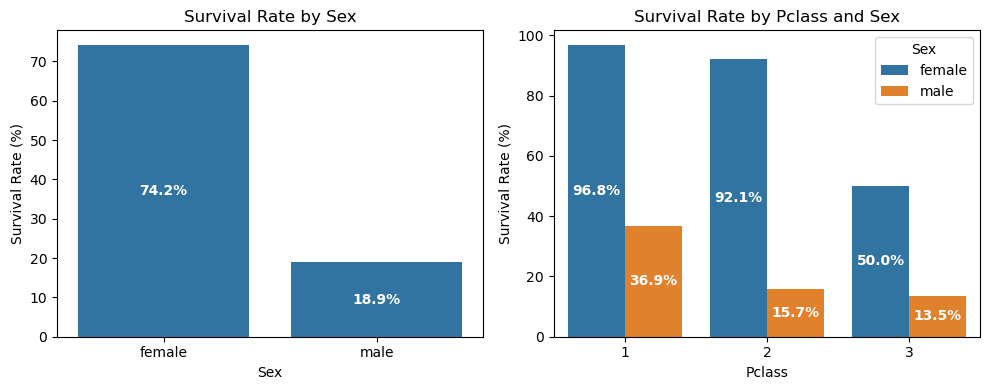

In [15]:
plt.figure(figsize=(10, 4))

df["Survived_Pct"] = df["Survived"] * 100

#plot 1
ax1 = plt.subplot(1, 2, 1)
sns.barplot(data=df, 
            x="Sex", 
            y="Survived_Pct",
            errorbar=None
            )
plt.title("Survival Rate by Sex")
plt.ylabel("Survival Rate (%)")
for c in ax1.containers:
  ax1.bar_label(
      c, fmt="%.1f%%", label_type="center", color="white", weight="bold"
  )

#plot 2
ax2 = plt.subplot(1, 2, 2)
sns.barplot(data=df, 
            x="Pclass", 
            y="Survived_Pct", 
            hue="Sex",
            errorbar=None
            )
plt.title("Survival Rate by Pclass and Sex")
plt.ylabel("Survival Rate (%)")
for c in ax2.containers:
  ax2.bar_label(
      c, fmt="%.1f%%", label_type="center", color="white", weight="bold"
  )

plt.tight_layout()
plt.show()

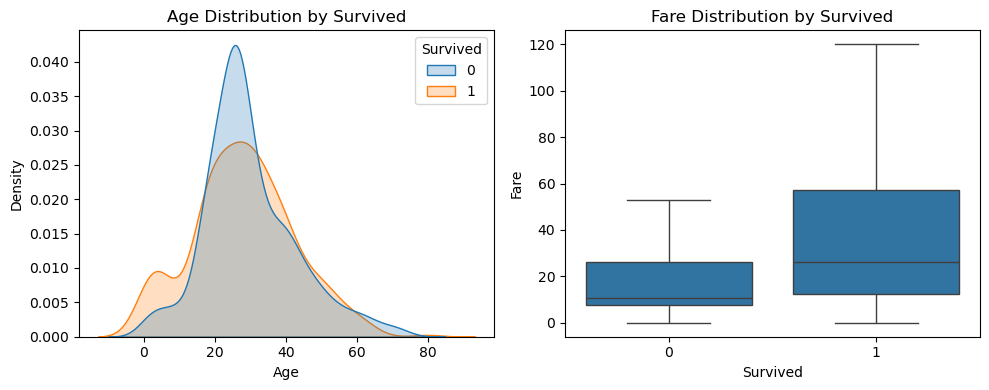

In [16]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.kdeplot(data=df, 
            x="Age", 
            hue="Survived", 
            common_norm=False, 
            fill=True)
plt.title("Age Distribution by Survived")

plt.subplot(1, 2, 2)
sns.boxplot(data=df, 
            x="Survived", 
            y="Fare", 
            showfliers=False)
plt.title("Fare Distribution by Survived")

plt.tight_layout()
plt.show()

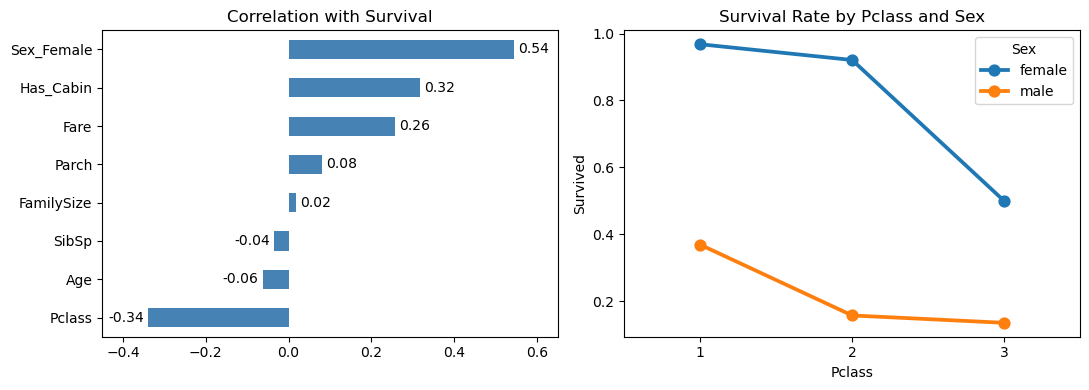

In [17]:
# Adding simple binary indicators
df['Sex_Female'] = (df['Sex'] == 'female').astype(int)
df['Has_Cabin'] = df['Cabin'].notnull().astype(int)
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

plt.figure(figsize=(11, 4))

# 1. Correlation bar
to_drop = ["Survived", "Survived_Pct", "PassengerId"]

corrs = (
    df.assign(Pclass=df["Pclass"].astype(int))
    .corr(numeric_only=True)["Survived"]
    .drop(to_drop, errors="ignore")  
    .sort_values()
)

plt.subplot(1, 2, 1)
ax = corrs.plot.barh(color="steelblue")
ax.bar_label(ax.containers[0], fmt="%.2f", padding=3)
plt.title("Correlation with Survival")
plt.xlim(-0.45, 0.65)

# 2. Interaction point plot
plt.subplot(1, 2, 2)
sns.pointplot(data=df, x='Pclass', y='Survived', hue='Sex', errorbar=None)
plt.title('Survival Rate by Pclass and Sex')

plt.tight_layout()
plt.show()